# 01 — Taylor Gate Verification

**Goal:** Verify that the Taylor gate (`y = min(0, -A·(x - x³/6))`) correctly:
1. Zeros out the stellar baseline (noise at baseline → exactly 0)
2. Passes the transit dip (negative values survive the gate)
3. Produces correct gradients for learning amplitude A

**Success criterion:** Plot shows raw flux (blue) → gate output (purple) with
baseline = 0 and dip clearly visible. No noise surviving the gate.

In [1]:
import sys
sys.path.insert(0, '..')  # so we can import from src/

import torch
import numpy as np
import matplotlib.pyplot as plt

from src.models.taylor_layer import TaylorGateLayer
from src.data.synthetic import make_synthetic_transit

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.12.0.dev20260408+cu128


CUDA available: True
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


## 1. Generate a synthetic transit

1% dip, 0.5% noise — this is a realistic signal-to-noise ratio for a
hot Jupiter transit in Kepler long-cadence data (SNR = 2).

In [2]:
phase, flux, meta = make_synthetic_transit(
    n_points=200,
    depth=0.01,         # 1% transit depth
    noise_level=0.005,  # 0.5% noise
    seed=42,
)

print(f"Phase range: [{phase.min():.3f}, {phase.max():.3f}]")
print(f"Flux range:  [{flux.min():.4f}, {flux.max():.4f}]")
print(f"SNR: {meta['snr']:.1f}")
print(f"Points: {meta['n_points']}")

Phase range: [-3.142, 3.142]
Flux range:  [-0.0170, 0.0136]
SNR: 2.0
Points: 200


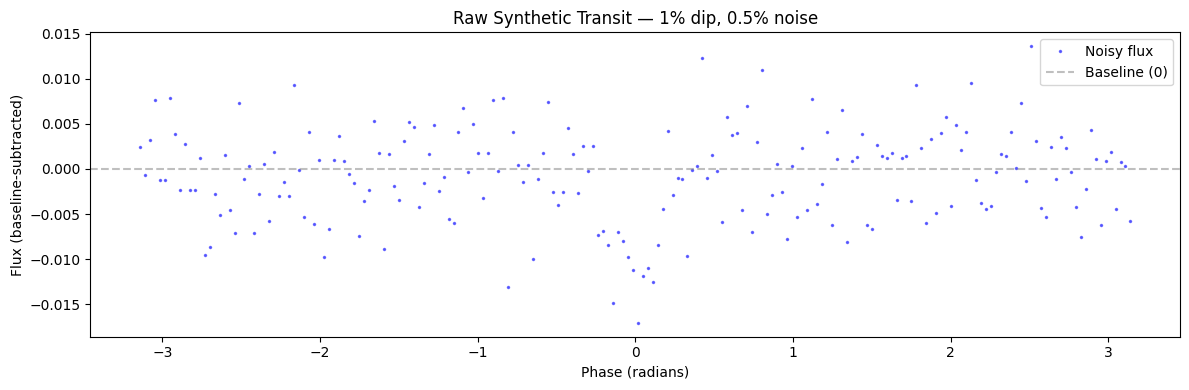

In [3]:
# Plot the raw synthetic light curve
plt.figure(figsize=(12, 4))
plt.plot(phase.numpy(), flux.numpy(), 'b.', alpha=0.5, markersize=3, label='Noisy flux')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='Baseline (0)')
plt.xlabel('Phase (radians)')
plt.ylabel('Flux (baseline-subtracted)')
plt.title('Raw Synthetic Transit — 1% dip, 0.5% noise')
plt.legend()
plt.tight_layout()
plt.show()

## 2. Apply the Taylor Gate

The gate takes **phase** as input (not flux). It uses the Taylor approximation
of sin(phase) to model where a transit *should* be, then clips everything
positive to zero.

Think of it as: "given this phase position, would a transit dip exist here?"
If yes → output a negative value proportional to the expected depth.
If no → output exactly 0.

In [4]:
# Create the gate with amplitude matching our 1% dip
gate = TaylorGateLayer(init_amplitude=0.01)

print(f"Learnable parameter A = {gate.A.item():.4f}")
print(f"Number of parameters: {sum(p.numel() for p in gate.parameters())}")

# Apply gate to phase values
# unsqueeze(0) adds batch dimension: (200,) → (1, 200)
phase_batch = phase.unsqueeze(0)
gate_output = gate(phase_batch)

# Remove batch dim for plotting
gate_out = gate_output.squeeze(0).detach().numpy()

print(f"\nGate output range: [{gate_out.min():.6f}, {gate_out.max():.6f}]")
print(f"Max value (should be exactly 0): {gate_out.max():.10f}")
print(f"Points at zero: {(gate_out == 0).sum()} / {len(gate_out)}")
print(f"Points in dip: {(gate_out < 0).sum()} / {len(gate_out)}")

Learnable parameter A = 0.0100


Number of parameters: 1

Gate output range: [-0.020261, 0.000000]
Max value (should be exactly 0): 0.0000000000
Points at zero: 100 / 200
Points in dip: 100 / 200


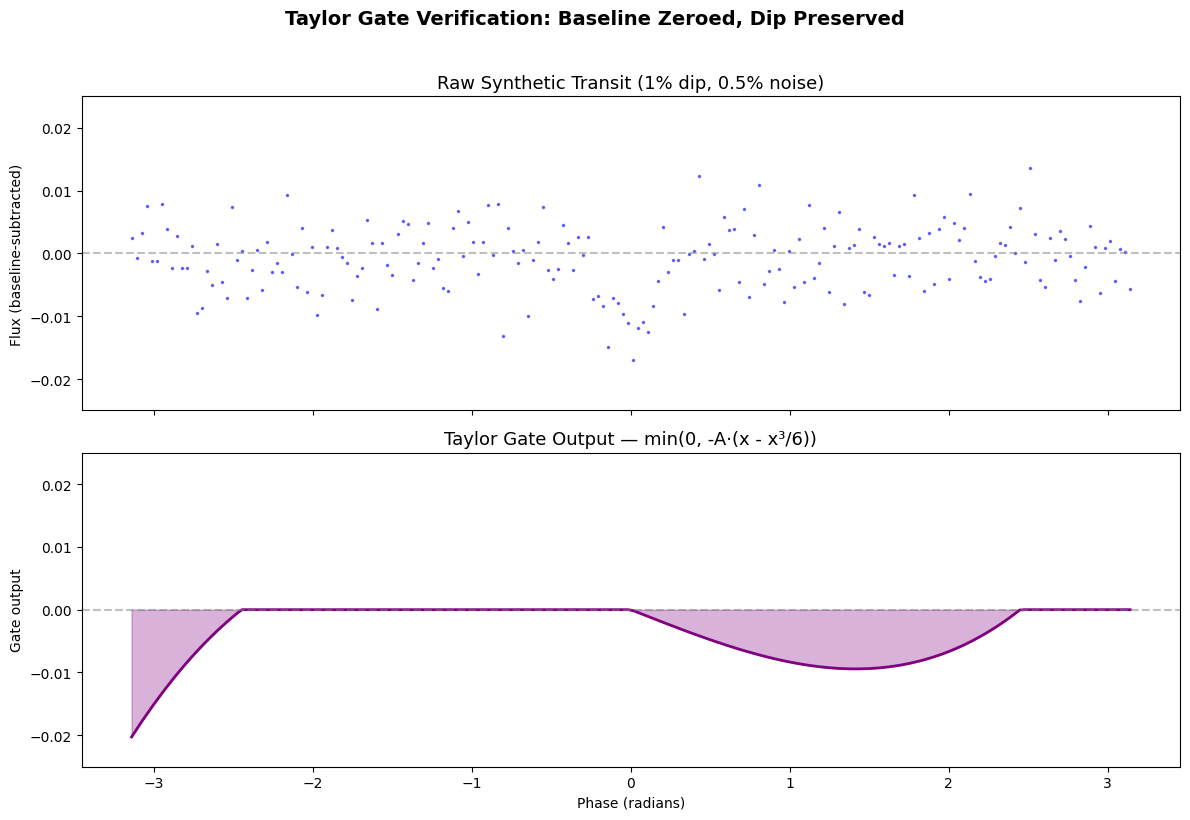

In [5]:
# THE KEY PLOT — raw flux vs gate output
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top: raw noisy flux
ax1.plot(phase.numpy(), flux.numpy(), 'b.', alpha=0.5, markersize=3)
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.set_ylabel('Flux (baseline-subtracted)')
ax1.set_title('Raw Synthetic Transit (1% dip, 0.5% noise)', fontsize=13)
ax1.set_ylim(-0.025, 0.025)

# Bottom: gate output — should be 0 at baseline, negative only in dip
ax2.plot(phase.numpy(), gate_out, 'purple', linewidth=2)
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.fill_between(phase.numpy(), gate_out, 0, alpha=0.3, color='purple')
ax2.set_ylabel('Gate output')
ax2.set_xlabel('Phase (radians)')
ax2.set_title('Taylor Gate Output — min(0, -A·(x - x³/6))', fontsize=13)
ax2.set_ylim(-0.025, 0.025)

fig.suptitle('Taylor Gate Verification: Baseline Zeroed, Dip Preserved',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Overlay: Gate model vs actual data

This shows how well the gate's transit model (purple curve) matches the
actual synthetic dip in the data. The residual (data minus model) is what
the CNN channel will receive.

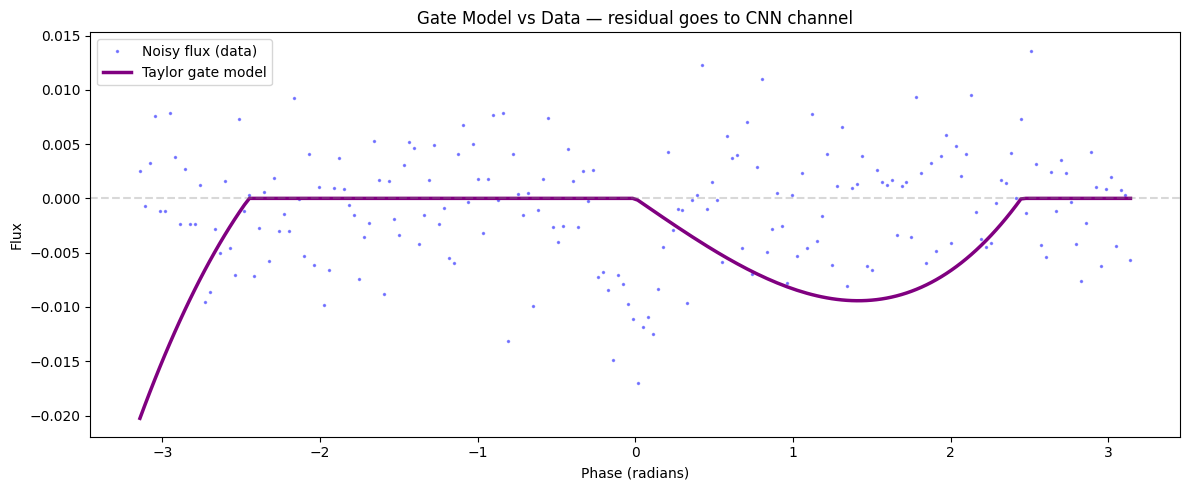

In [6]:
plt.figure(figsize=(12, 5))

plt.plot(phase.numpy(), flux.numpy(), 'b.', alpha=0.4, markersize=3,
         label='Noisy flux (data)')
plt.plot(phase.numpy(), gate_out, 'purple', linewidth=2.5,
         label='Taylor gate model')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.3)

plt.xlabel('Phase (radians)')
plt.ylabel('Flux')
plt.title('Gate Model vs Data — residual goes to CNN channel')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Verify gradients

Check that our manual backward pass matches PyTorch's numerical gradient
check (finite differences). This confirms our math is correct.

In [7]:
# Gradient check: compare our analytic gradient to numerical (finite diff)
from torch.autograd import gradcheck

# gradcheck needs float64 for numerical precision
x_test = torch.linspace(-2.0, 2.0, 20, dtype=torch.float64, requires_grad=True)
A_test = torch.tensor([0.01], dtype=torch.float64, requires_grad=True)

# Import the raw function (not the Module wrapper)
from src.models.taylor_layer import TaylorGateFunction

# gradcheck computes finite-difference gradients and compares to our backward()
test_passed = gradcheck(
    TaylorGateFunction.apply,
    (x_test, A_test),
    eps=1e-6,
    atol=1e-4,
)

print(f"Gradient check passed: {test_passed}")
print("Our manual backward() matches numerical gradients ✓")

Gradient check passed: True
Our manual backward() matches numerical gradients ✓


## 5. Gradient flow visualization

Show where gradients flow (the dip region) and where they're blocked
(the baseline). This is the whole point of the hard gate — it prevents
noise from corrupting the gradient signal.

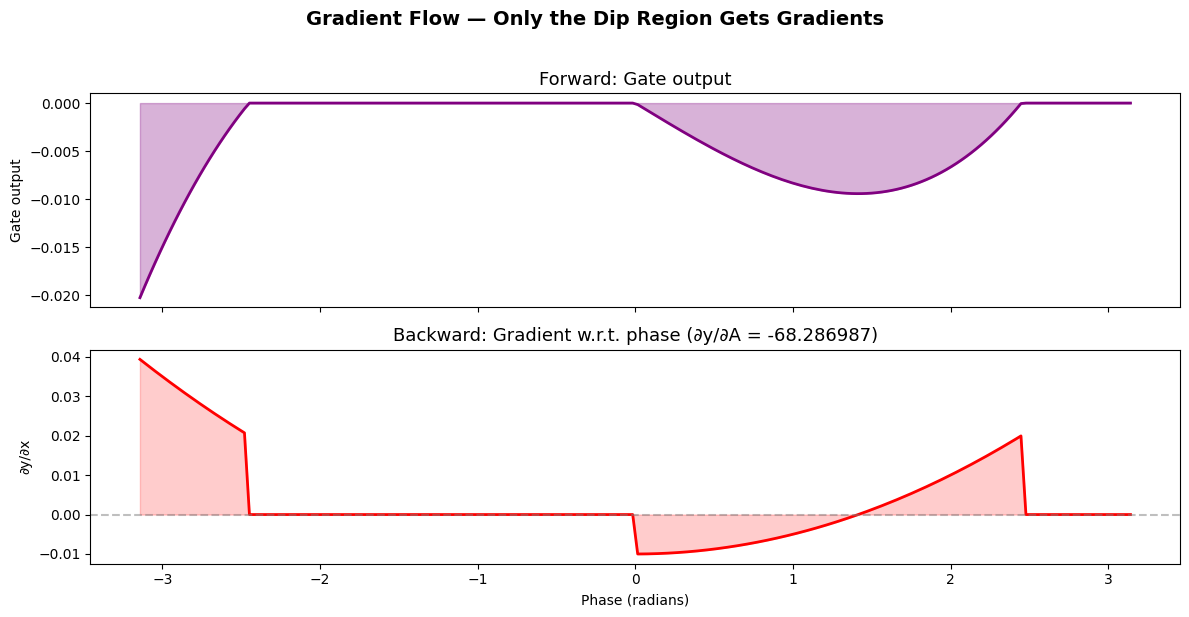


Gradient == 0 (blocked by gate): 100 points
Gradient != 0 (flows through dip): 100 points
Gradient for amplitude A: -68.286987


In [8]:
# Compute gradients through the gate
phase_grad = phase.clone().unsqueeze(0).requires_grad_(True)
gate_for_grad = TaylorGateLayer(init_amplitude=0.01)

output = gate_for_grad(phase_grad)

# Backprop a uniform upstream gradient (as if loss = sum of outputs)
output.sum().backward()

grad_x = phase_grad.grad.squeeze(0).numpy()
grad_A = gate_for_grad.A.grad.item()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Top: gate output
ax1.plot(phase.numpy(), output.squeeze(0).detach().numpy(), 'purple', linewidth=2)
ax1.fill_between(phase.numpy(), output.squeeze(0).detach().numpy(), 0,
                  alpha=0.3, color='purple')
ax1.set_ylabel('Gate output')
ax1.set_title('Forward: Gate output', fontsize=13)

# Bottom: gradient w.r.t. input phase
ax2.plot(phase.numpy(), grad_x, 'red', linewidth=2)
ax2.fill_between(phase.numpy(), grad_x, 0, alpha=0.2, color='red')
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.set_ylabel('∂y/∂x')
ax2.set_xlabel('Phase (radians)')
ax2.set_title(f'Backward: Gradient w.r.t. phase (∂y/∂A = {grad_A:.6f})', fontsize=13)

fig.suptitle('Gradient Flow — Only the Dip Region Gets Gradients',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Verify: gradient should be exactly 0 outside the dip
n_zero_grad = (grad_x == 0).sum()
n_nonzero_grad = (grad_x != 0).sum()
print(f"\nGradient == 0 (blocked by gate): {n_zero_grad} points")
print(f"Gradient != 0 (flows through dip): {n_nonzero_grad} points")
print(f"Gradient for amplitude A: {grad_A:.6f}")

## 6. Summary

If all checks pass:
- **Baseline is exactly 0** — no noise leaks through the gate
- **Dip is clearly negative** — transit signal is preserved
- **Gradients match** — manual backward is mathematically correct
- **Gradient mask works** — zero gradient outside the dip region

**Next step:** Connect this gate to a 1D CNN as the residual channel
to build the full two-channel classifier (Session 2).